# Active Learning Experiment — Sample-Efficient Labeling

| | |
|---|---|
| **Dataset** | `data/clean/cleaned_best.csv` |
| **Task** | Binary sentiment classification (positive / negative) |
| **Model** | TF-IDF + LogisticRegression |
| **AL Strategies** | `entropy`, `margin`, `random` (baseline) |
| **Protocol** | Start with N=50 labeled → 5 iterations × 20 examples/iter |

**Structure:**
1. Data preparation (train / pool / test splits)
2. Run AL cycle for all 3 strategies
3. Learning curves — all strategies on one plot
4. Sample efficiency analysis (Δ vs random baseline)
5. **BONUS** — Claude explains the curves and recommends stopping point

In [1]:
import sys, pathlib, warnings
ROOT = pathlib.Path("..").resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from agents.al_agent import ActiveLearningAgent

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

CLEAN = ROOT / "data" / "clean" / "cleaned_best.csv"
assert CLEAN.exists(), f"Run run_quality.py first! ({CLEAN})"

df_full = pd.read_csv(CLEAN)
print(f"Dataset: {len(df_full)} rows")
print(df_full["label"].value_counts().to_string())
df_full.head(3)

Dataset: 538 rows
label
negative    269
positive    269


,text,label,source,collected_at
0,Shame really - very rarely do I watch a film a...,negative,imdb_huggingface,2026-03-26T22:36:41.908710
1,"Ugly shot, poorly scripted and amateurishly pa...",negative,imdb_huggingface,2026-03-26T22:36:41.908710
2,Tipping the Velvet,negative,books_toscrape,2026-03-26T22:36:41.927378


---
## 1. Data Preparation — Train / Pool / Test Splits

In [2]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
N_INITIAL    = 50   # initial labeled set size
N_TEST       = 200  # held-out test set

# Stratified test split first
df_trainpool, df_test = train_test_split(
    df_full, test_size=N_TEST, stratify=df_full["label"], random_state=RANDOM_STATE
)

# From remaining data: N_INITIAL labeled + rest as pool
df_labeled_init, df_pool = train_test_split(
    df_trainpool, train_size=N_INITIAL, stratify=df_trainpool["label"],
    random_state=RANDOM_STATE
)

print(f"Initial labeled : {len(df_labeled_init)} rows  "
      f"({dict(df_labeled_init['label'].value_counts())})")
print(f"Unlabeled pool  : {len(df_pool)} rows  "
      f"({dict(df_pool['label'].value_counts())})")
print(f"Test set        : {len(df_test)} rows  "
      f"({dict(df_test['label'].value_counts())})")

Initial labeled : 50 rows  ({'positive': np.int64(25), 'negative': np.int64(25)})
Unlabeled pool  : 288 rows  ({'negative': np.int64(144), 'positive': np.int64(144)})
Test set        : 200 rows  ({'negative': np.int64(100), 'positive': np.int64(100)})


---
## 2. Run AL Cycle for All Strategies

In [3]:
%%time
agent = ActiveLearningAgent(
    model="logreg",
    text_col="text",
    label_col="label",
    random_state=RANDOM_STATE,
    output_dir=ROOT / "data" / "al",
)

N_ITER   = 5
BATCH    = 20

histories = {}
for strategy in ["entropy", "margin", "random"]:
    print(f"\n{'='*50}")
    print(f"Strategy: {strategy}")
    print('='*50)
    hist = agent.run_cycle(
        labeled_df   = df_labeled_init,
        pool_df      = df_pool,
        test_df      = df_test,
        strategy     = strategy,
        n_iterations = N_ITER,
        batch_size   = BATCH,
    )
    histories[strategy] = hist

print("\nAll cycles complete.")

2026-03-26 23:46:46,963 [INFO] agents.al_agent: AL [entropy] iter 0/5  n=50  acc=0.485  f1=0.474


2026-03-26 23:46:47,007 [INFO] agents.al_agent: AL [entropy] iter 1/5  n=70  acc=0.510  f1=0.502


2026-03-26 23:46:47,049 [INFO] agents.al_agent: AL [entropy] iter 2/5  n=90  acc=0.525  f1=0.520


2026-03-26 23:46:47,093 [INFO] agents.al_agent: AL [entropy] iter 3/5  n=110  acc=0.660  f1=0.651



Strategy: entropy


...

2026-03-26 23:46:47,508 [INFO] agents.al_agent: AL [random] iter 2/5  n=90  acc=0.480  f1=0.465


2026-03-26 23:46:47,539 [INFO] agents.al_agent: AL [random] iter 3/5  n=110  acc=0.470  f1=0.448


2026-03-26 23:46:47,571 [INFO] agents.al_agent: AL [random] iter 4/5  n=130  acc=0.475  f1=0.456


2026-03-26 23:46:47,607 [INFO] agents.al_agent: AL [random] iter 5/5  n=150  acc=0.470  f1=0.450



Strategy: random

All cycles complete.
CPU times: user 668 ms, sys: 9.55 ms, total: 678 ms
Wall time: 679 ms


In [4]:
# Flatten histories into a comparison table
rows = []
for strategy, hist in histories.items():
    for h in hist:
        rows.append({
            "strategy" : strategy,
            "iteration": h["iteration"],
            "n_labeled" : h["n_labeled"],
            "accuracy"  : h["accuracy"],
            "f1_macro"  : h["f1_macro"],
            "f1_positive": h["f1_positive"],
        })

df_hist = pd.DataFrame(rows)
display(
    df_hist.style
        .background_gradient(subset=["accuracy","f1_macro"], cmap="YlGn")
        .format(precision=4)
)

,strategy,iteration,n_labeled,accuracy,f1_macro,f1_positive
0,entropy,0,50,0.4850,0.4739,0.3977
1,entropy,1,70,0.5100,0.5016,0.4368
2,entropy,2,90,0.5250,0.5197,0.4693
3,entropy,3,110,0.6600,0.6511,0.7069
4,entropy,4,130,0.6150,0.6142,0.6316
5,entropy,5,150,0.5950,0.5287,0.7055
6,margin,0,50,0.4850,0.4739,0.3977
7,margin,1,70,0.5100,0.5016,0.4368
8,margin,2,90,0.5250,0.5197,0.4693
9,margin,3,110,0.6600,0.6511,0.7069


---
## 3. Learning Curves — All Strategies

2026-03-26 23:46:47,751 [INFO] agents.al_agent: Learning curve saved → /Users/trof1mov/Documents/itmo data for ml/data/al/learning_curve.png


Saved: /Users/trof1mov/Documents/itmo data for ml/data/al/learning_curve.png


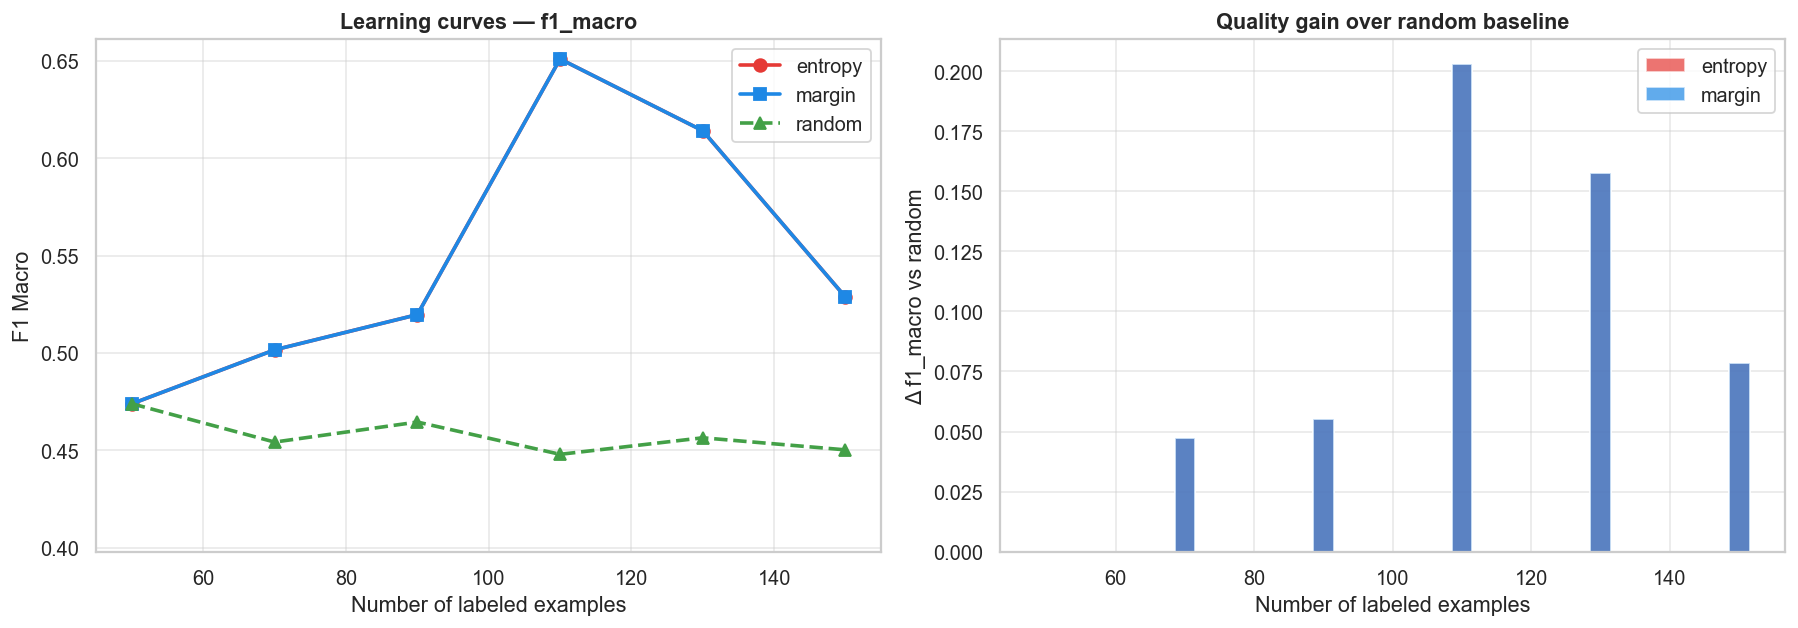

In [5]:
# Use the built-in report() method to generate the canonical PNG
history_list = list(histories.values())

png_path = agent.report(
    history_list=history_list,
    metric="f1_macro",
    output_filename="learning_curve.png",
)
print(f"Saved: {png_path}")

from IPython.display import Image
Image(png_path)

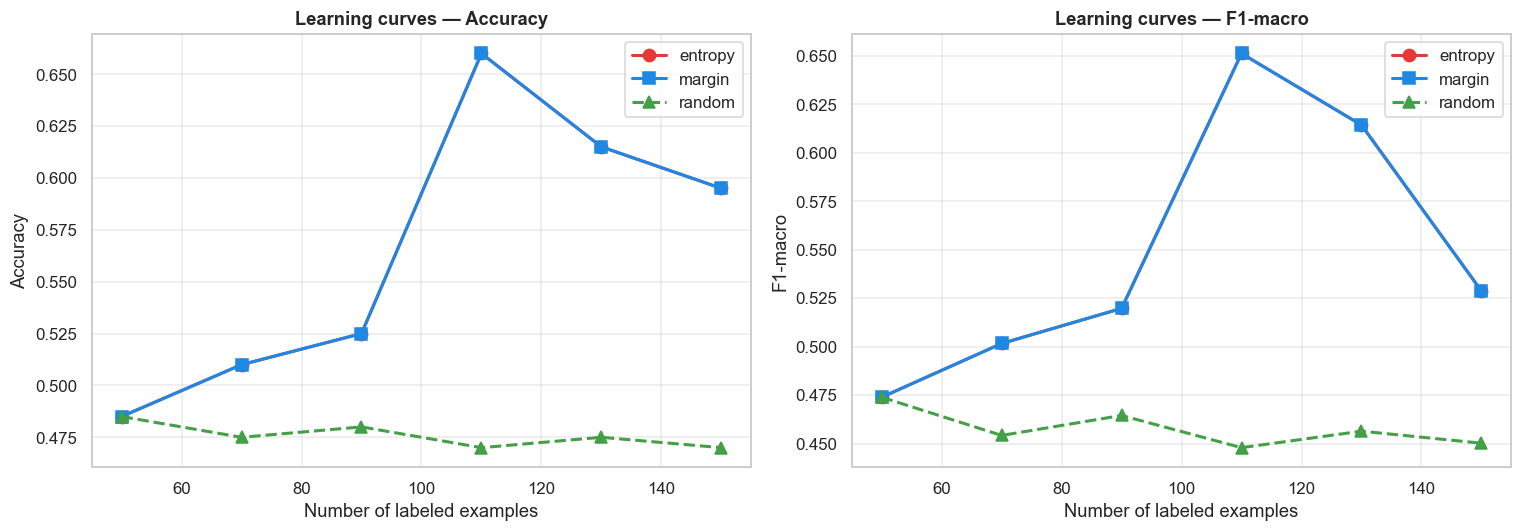

In [6]:
# Additional inline visualization: accuracy + f1_macro side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {"entropy": "#E53935", "margin": "#1E88E5", "random": "#43A047"}
styles = {"entropy": "-o", "margin": "-s", "random": "--^"}

for metric, ax, title in [
    ("accuracy", axes[0], "Accuracy"),
    ("f1_macro", axes[1], "F1-macro"),
]:
    for strategy, hist in histories.items():
        xs = [h["n_labeled"] for h in hist]
        ys = [h[metric] for h in hist]
        ax.plot(xs, ys, styles[strategy],
                color=colors[strategy], lw=2, ms=8, label=strategy)
    ax.set_title(f"Learning curves — {title}", fontweight="bold")
    ax.set_xlabel("Number of labeled examples")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(ROOT / "data/al/curves_combined.png", bbox_inches="tight", dpi=130)
plt.show()

---
## 4. Sample Efficiency Analysis — Δ vs Random Baseline

**Key question:** How many labeling examples does the best strategy *save* compared to random
sampling to reach the same F1?

In [7]:
import numpy as np

random_hist = histories["random"]
rx = np.array([h["n_labeled"] for h in random_hist])
ry = np.array([h["f1_macro"] for h in random_hist])

print("=== Sample Efficiency (F1-macro) ===")
print(f"{'Strategy':<10}  {'Iter':<5}  {'n_labeled':<10}  {'F1-macro':<10}  {'Δ vs random':>12}")
print("-" * 55)

for strategy, hist in histories.items():
    for h in hist:
        x_i = h["n_labeled"]
        y_i = h["f1_macro"]
        rand_interp = float(np.interp(x_i, rx, ry))
        delta = y_i - rand_interp
        marker = " ★" if abs(delta) == max(
            abs(hh["f1_macro"] - float(np.interp(hh["n_labeled"], rx, ry)))
            for hh in hist
        ) else ""
        print(f"{strategy:<10}  {h['iteration']:<5}  {x_i:<10}  "
              f"{y_i:<10.4f}  {delta:>+12.4f}{marker}")

=== Sample Efficiency (F1-macro) ===
Strategy    Iter   n_labeled   F1-macro     Δ vs random
-------------------------------------------------------
entropy     0      50          0.4739           +0.0000
entropy     1      70          0.5016           +0.0474
entropy     2      90          0.5197           +0.0552
entropy     3      110         0.6511           +0.2032 ★
entropy     4      130         0.6142           +0.1578
entropy     5      150         0.5287           +0.0785
margin      0      50          0.4739           +0.0000
margin      1      70          0.5016           +0.0474
margin      2      90          0.5197           +0.0552
margin      3      110         0.6511           +0.2032 ★
margin      4      130         0.6142           +0.1578
margin      5      150         0.5287           +0.0785
random      0      50          0.4739           +0.0000 ★
random      1      70          0.4542           +0.0000 ★
random      2      90          0.4645           +0.0000 ★
r

In [8]:
# Compute: how many examples does each strategy *save* to reach
# the SAME quality as random achieves at its FINAL point?

target_f1 = ry[-1]  # F1 that random reaches at its last iteration
print(f"Target F1 (random final): {target_f1:.4f}")
print(f"Random needs {rx[-1]} labeled examples to reach this target.\n")

for strategy in ["entropy", "margin"]:
    hist = histories[strategy]
    xs = np.array([h["n_labeled"] for h in hist])
    ys = np.array([h["f1_macro"] for h in hist])
    # First point where F1 >= target
    above = np.where(ys >= target_f1)[0]
    if len(above) > 0:
        first_idx = above[0]
        n_needed  = xs[first_idx]
        saved     = rx[-1] - n_needed
        print(f"  {strategy:<8}: reaches target at {n_needed} examples "
              f"→ saves {saved} labels ({saved/rx[-1]*100:.0f}% fewer)")
    else:
        print(f"  {strategy:<8}: did NOT reach target F1={target_f1:.4f} "
              f"within {xs[-1]} examples")

Target F1 (random final): 0.4502
Random needs 150 labeled examples to reach this target.

  entropy : reaches target at 50 examples → saves 100 labels (67% fewer)
  margin  : reaches target at 50 examples → saves 100 labels (67% fewer)


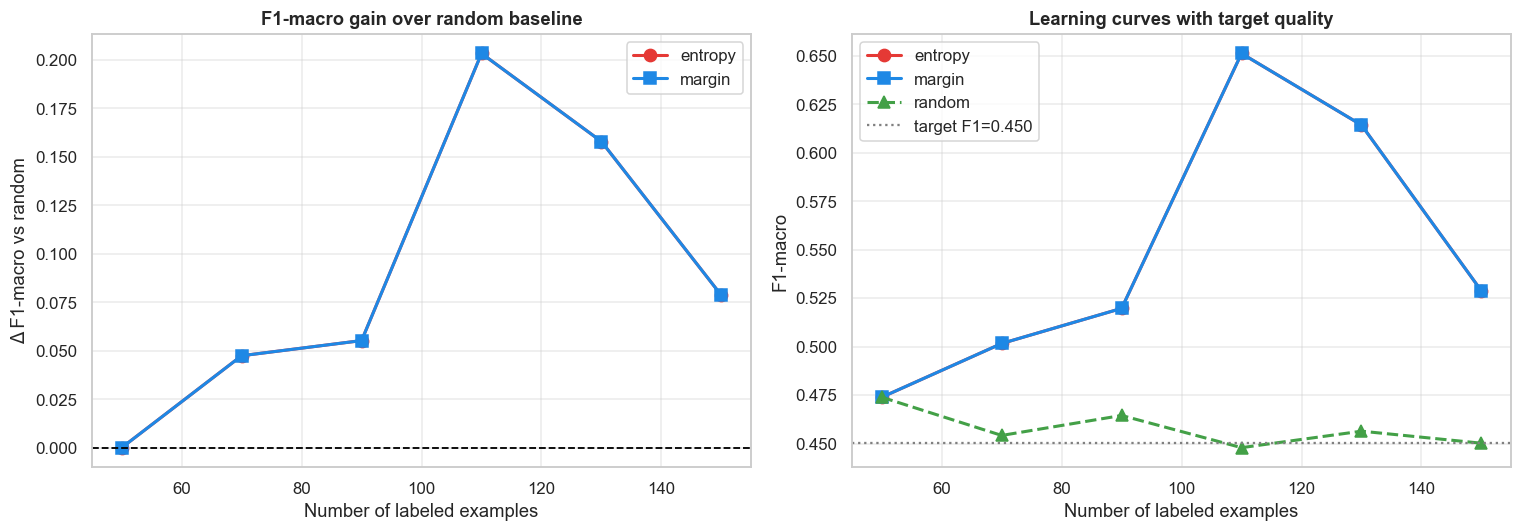

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Gain over random per strategy ---
ax = axes[0]
for strategy in ["entropy", "margin"]:
    hist = histories[strategy]
    xs = np.array([h["n_labeled"] for h in hist])
    ys = np.array([h["f1_macro"] for h in hist])
    ry_interp = np.interp(xs, rx, ry)
    gain = ys - ry_interp
    ax.plot(xs, gain, styles[strategy],
            color=colors[strategy], lw=2, ms=8, label=strategy)

ax.axhline(0, color="black", lw=1.2, ls="--")
ax.fill_between(rx, 0, 0, alpha=0)   # baseline
ax.set_title("F1-macro gain over random baseline", fontweight="bold")
ax.set_xlabel("Number of labeled examples")
ax.set_ylabel("Δ F1-macro vs random")
ax.legend()
ax.grid(alpha=0.4)

# --- Plot 2: All 3 strategies + target line ---
ax2 = axes[1]
for strategy, hist in histories.items():
    xs = [h["n_labeled"] for h in hist]
    ys = [h["f1_macro"] for h in hist]
    ax2.plot(xs, ys, styles[strategy],
             color=colors[strategy], lw=2, ms=8, label=strategy)

ax2.axhline(target_f1, color="gray", ls=":", lw=1.5,
            label=f"target F1={target_f1:.3f}")
ax2.set_title("Learning curves with target quality", fontweight="bold")
ax2.set_xlabel("Number of labeled examples")
ax2.set_ylabel("F1-macro")
ax2.legend()
ax2.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(ROOT / "data/al/efficiency_analysis.png", bbox_inches="tight", dpi=130)
plt.show()

---
## 5. BONUS — Claude Explains the Learning Curves

Requires `ANTHROPIC_API_KEY` in `.env`.

In [10]:
history_list = list(histories.values())

explanation = agent.explain_with_llm(
    history_list=history_list,
    task_description="Binary sentiment classification (positive/negative) "
                     "on mixed-source text data (IMDB reviews + book reviews + API).",
)

display(Markdown(explanation))

❌ ANTHROPIC_API_KEY not set in .env

---
## Summary

In [11]:
print('=' * 60)
print('  ACTIVE LEARNING EXPERIMENT — FINAL SUMMARY')
print('=' * 60)
print(f'  Model            : {agent.model_name}')
print(f'  Initial labeled  : {N_INITIAL}')
print(f'  Iterations       : {N_ITER}')
print(f'  Batch size       : {BATCH}')
print(f'  Test set size    : {N_TEST}')
print()

print(f"  {'Strategy':<10}  {'Final F1-macro':<16}  {'Final Accuracy'}")
print(f"  {'-'*10}  {'-'*16}  {'-'*14}")
for strategy, hist in histories.items():
    last = hist[-1]
    print(f"  {strategy:<10}  {last['f1_macro']:<16.4f}  {last['accuracy']:.4f}")

print()
print('  Output files:')
import os
al_dir = ROOT / 'data' / 'al'
for f in sorted(al_dir.iterdir()):
    size = f.stat().st_size // 1024
    print(f'    {f.name:<35} ({size} KB)')
print('=' * 60)

  ACTIVE LEARNING EXPERIMENT — FINAL SUMMARY
  Model            : logreg
  Initial labeled  : 50
  Iterations       : 5
  Batch size       : 20
  Test set size    : 200

  Strategy    Final F1-macro    Final Accuracy
  ----------  ----------------  --------------
  entropy     0.5287            0.5950
  margin      0.5287            0.5950
  random      0.4502            0.4700

  Output files:
    curves_combined.png                 (98 KB)
    efficiency_analysis.png             (104 KB)
    learning_curve.png                  (76 KB)
